# Диагностика и классификация неисправностей по сигналам датчиков

**Курс:** Интеллектуальные измерительные системы

**Задача:** по сигналам вибрации и тока электродвигателя определить
техническое состояние оборудования: норма или один из видов неисправности.

Используются **синтетические сигналы**, имитирующие показания датчика
вибрации (акселерометра) и датчика тока, для четырёх состояний:

1. **Норма** — исправный двигатель
2. **Дисбаланс ротора** — повышенная амплитуда на оборотной частоте
3. **Дефект подшипника** — высокочастотные импульсные составляющие
4. **Несоосность (misalignment)** — выраженные 2-я и 3-я гармоники оборотной частоты

Пайплайн: генерация сигналов → извлечение признаков (временная и частотная
область) → обучение классификатора → оценка качества → диагностика на
новом сигнале.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rng = np.random.default_rng(7)

FS = 5000          # частота дискретизации, Гц
DURATION = 1.0      # длительность сигнала, с
T = np.arange(0, DURATION, 1 / FS)
F_ROT = 25.0         # оборотная частота двигателя, Гц (1500 об/мин)


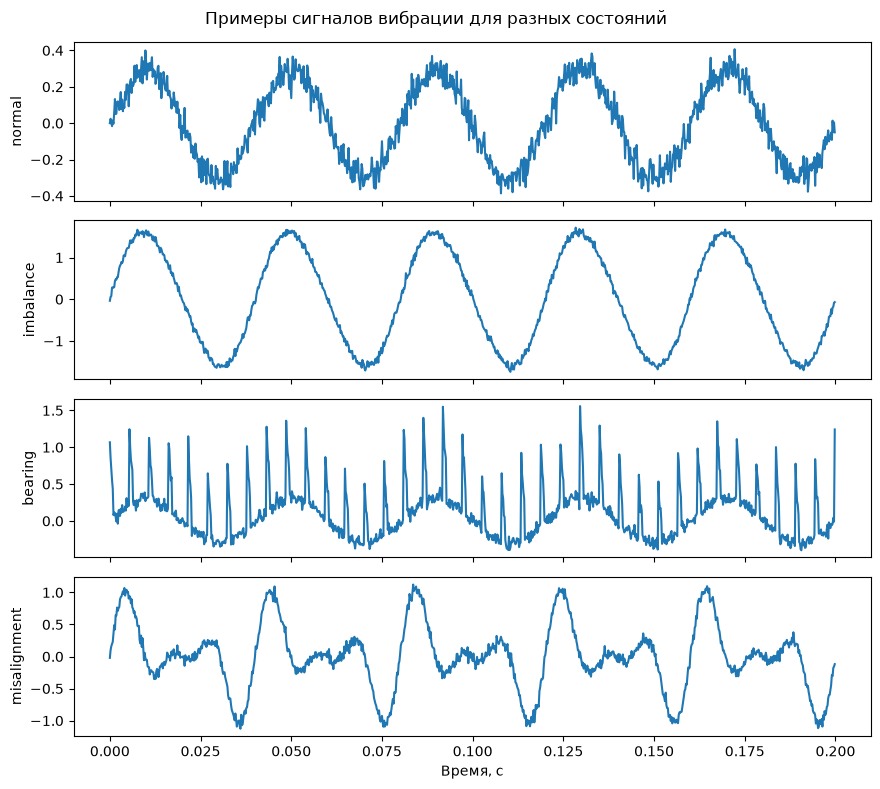

In [2]:
def generate_signal(fault_type, rng):
    """Генерирует пару сигналов (вибрация, ток) для заданного типа состояния."""
    noise_v = 0.05 * rng.standard_normal(len(T))
    noise_i = 0.03 * rng.standard_normal(len(T))

    if fault_type == 'normal':
        vib = 0.3 * np.sin(2 * np.pi * F_ROT * T) + noise_v
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + noise_i

    elif fault_type == 'imbalance':
        # рост амплитуды на оборотной частоте
        amp = rng.uniform(1.2, 1.6)
        vib = amp * np.sin(2 * np.pi * F_ROT * T) + 0.1 * np.sin(2 * np.pi * 50 * T) + noise_v
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + 0.08 * np.sin(2 * np.pi * F_ROT * T) + noise_i

    elif fault_type == 'bearing':
        # высокочастотные импульсы (удары) поверх базовой вибрации
        vib = 0.3 * np.sin(2 * np.pi * F_ROT * T) + noise_v
        impact_freq = 180.0  # частота дефекта подшипника, Гц
        impacts = np.zeros(len(T))
        period_samples = int(FS / impact_freq)
        for start in range(0, len(T), period_samples):
            width = 5
            end = min(start + width, len(T))
            impacts[start:end] += rng.uniform(0.8, 1.4)
        envelope = np.exp(-((np.arange(len(T)) % period_samples) / (period_samples * 0.15)))
        vib += 0.9 * impacts * envelope
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + noise_i

    elif fault_type == 'misalignment':
        # выраженные 2-я и 3-я гармоники оборотной частоты
        vib = (0.3 * np.sin(2 * np.pi * F_ROT * T)
               + 0.55 * np.sin(2 * np.pi * 2 * F_ROT * T)
               + 0.35 * np.sin(2 * np.pi * 3 * F_ROT * T)
               + noise_v)
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + 0.1 * np.sin(2 * np.pi * 2 * F_ROT * T) + noise_i

    else:
        raise ValueError(fault_type)

    return vib, cur


fault_types = ['normal', 'imbalance', 'bearing', 'misalignment']

fig, axes = plt.subplots(len(fault_types), 1, figsize=(9, 8), sharex=True)
for ax, ft in zip(axes, fault_types):
    vib, _ = generate_signal(ft, rng)
    ax.plot(T[:1000], vib[:1000])
    ax.set_ylabel(ft)
axes[-1].set_xlabel('Время, с')
fig.suptitle('Примеры сигналов вибрации для разных состояний')
plt.tight_layout()
plt.show()


In [3]:
def extract_features(vib, cur):
    feats = {}
    for name, sig in [('vib', vib), ('cur', cur)]:
        feats[f'{name}_rms'] = np.sqrt(np.mean(sig ** 2))
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_peak'] = np.max(np.abs(sig))
        feats[f'{name}_crest'] = feats[f'{name}_peak'] / (feats[f'{name}_rms'] + 1e-9)
        feats[f'{name}_kurtosis'] = kurtosis(sig)
        feats[f'{name}_skew'] = skew(sig)

        spectrum = np.abs(rfft(sig))
        freqs = rfftfreq(len(sig), d=1 / FS)
        feats[f'{name}_dom_freq'] = freqs[np.argmax(spectrum)]
        feats[f'{name}_spec_energy'] = np.sum(spectrum ** 2)

        # энергия в полосе высоких частот (характерно для дефекта подшипника)
        hf_mask = freqs > 150
        feats[f'{name}_hf_energy_ratio'] = (
            np.sum(spectrum[hf_mask] ** 2) / (np.sum(spectrum ** 2) + 1e-9)
        )
    return feats


n_samples_per_class = 120
rows = []
for ft in fault_types:
    for _ in range(n_samples_per_class):
        vib, cur = generate_signal(ft, rng)
        feats = extract_features(vib, cur)
        feats['label'] = ft
        rows.append(feats)

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(480, 19)


,vib_rms,vib_std,vib_peak,vib_crest,vib_kurtosis,vib_skew,vib_dom_freq,vib_spec_energy,vib_hf_energy_ratio,cur_rms,cur_std,cur_peak,cur_crest,cur_kurtosis,cur_skew,cur_dom_freq,cur_spec_energy,cur_hf_energy_ratio,label
0,0.216887,0.216885,0.439724,2.027436,-1.336454,-0.012355,25.0,588007.746774,0.050003,0.707337,0.707337,1.073351,1.517454,-1.492419,0.000389,50.0,6.254077e+06,0.001671,normal
1,0.218674,0.218671,0.447644,2.047086,-1.350693,-0.005498,25.0,597743.868615,0.048972,0.707783,0.707783,1.076633,1.521133,-1.496294,0.001867,50.0,6.261973e+06,0.001671,normal
2,0.216416,0.216413,0.470144,2.172412,-1.327731,-0.002609,25.0,585463.835563,0.052005,0.708294,0.708294,1.082919,1.528910,-1.494526,0.002102,50.0,6.271015e+06,0.001711,normal
3,0.217212,0.217212,0.445803,2.052386,-1.344154,-0.006609,25.0,589769.591026,0.050362,0.707701,0.707700,1.094250,1.546204,-1.494575,-0.000559,50.0,6.260503e+06,0.001701,normal
4,0.217890,0.217889,0.451995,2.074419,-1.368793,0.001561,25.0,593453.881583,0.049247,0.707308,0.707307,1.075750,1.520909,-1.496585,0.000031,50.0,6.253557e+06,0.001681,normal


In [4]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=0)
clf.fit(X_train_scaled, y_train)

preds = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, preds)
print('Accuracy:', round(acc, 4))
print(classification_report(y_test, preds))


Accuracy: 1.0
              precision    recall  f1-score   support

     bearing       1.00      1.00      1.00        30
   imbalance       1.00      1.00      1.00        30
misalignment       1.00      1.00      1.00        30
      normal       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



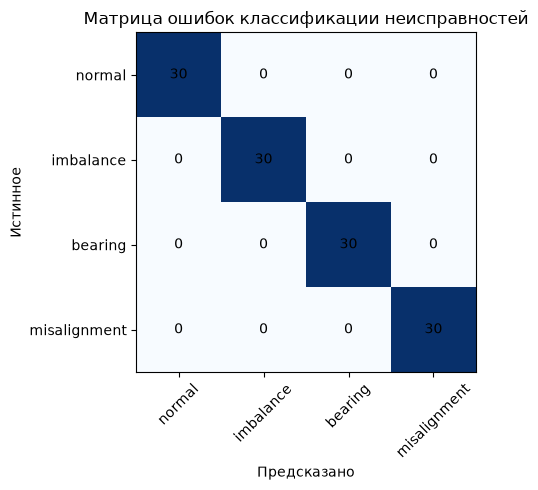

In [5]:
labels_order = fault_types
cm = confusion_matrix(y_test, preds, labels=labels_order)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45)
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинное')
ax.set_title('Матрица ошибок классификации неисправностей')
plt.tight_layout()
plt.show()


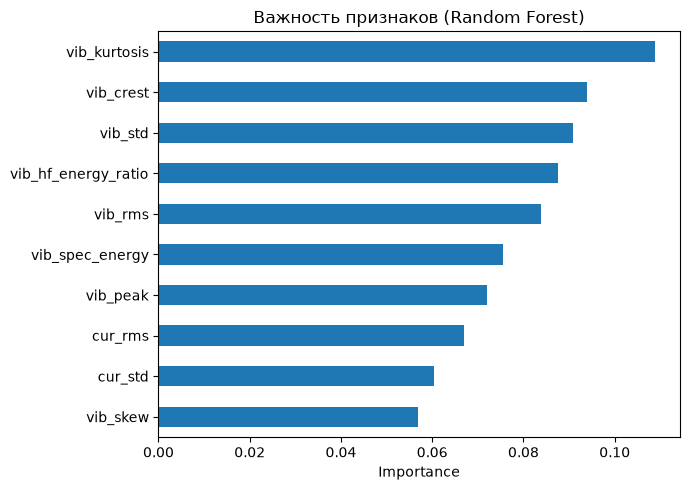

vib_kurtosis           0.108869
vib_crest              0.093935
vib_std                0.090836
vib_hf_energy_ratio    0.087510
vib_rms                0.083889
vib_spec_energy        0.075617
vib_peak               0.071984
cur_rms                0.067013
cur_std                0.060497
vib_skew               0.056831
dtype: float64


In [6]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(10))


In [7]:
# Диагностика на новом, ранее не встречавшемся сигнале
test_fault = 'bearing'
vib_new, cur_new = generate_signal(test_fault, np.random.default_rng(999))
feats_new = pd.DataFrame([extract_features(vib_new, cur_new)])
feats_new_scaled = scaler.transform(feats_new)

predicted_state = clf.predict(feats_new_scaled)[0]
probs = clf.predict_proba(feats_new_scaled)[0]

print('Истинное состояние:', test_fault)
print('Предсказанное состояние:', predicted_state)
for cls, p in zip(clf.classes_, probs):
    print(f'  P({cls}) = {p:.3f}')


Истинное состояние: bearing
Предсказанное состояние: bearing
  P(bearing) = 1.000
  P(imbalance) = 0.000
  P(misalignment) = 0.000
  P(normal) = 0.000


## Вывод

Признаки временной области (RMS, эксцесс, крест-фактор) и частотной области
(доминирующая частота, доля высокочастотной энергии) в сочетании со
случайным лесом позволяют надёжно различать норму и три типа неисправностей
(дисбаланс, дефект подшипника, несоосность) по синтетическим сигналам
вибрации и тока. Наибольшую информативность показали признаки, связанные с
эксцессом и высокочастотной энергией вибрации — что согласуется с физикой
дефекта подшипника (импульсные удары) — и амплитудные признаки вибрации для
дисбаланса/несоосности.

В реальной измерительной системе тот же пайплайн (извлечение признаков →
классификатор) применяется к сигналам, полученным с реальных датчиков
вибрации и тока электродвигателя.
